# End-to-End Loan Approval Prediction System
## Phase 1: Problem Formulation, Ingestion & Data Quality Analysis

### 1. Business Problem
Financial institutions face a classic credit risk trade-off:
- **Under-approving loans** turns away creditworthy applicants, resulting in lost interest revenue and customer churn.
- **Over-approving loans** to risky borrowers results in loan defaults, costly recovery operations, and severe capital loss.

Manual underwriting is slow, inconsistent, and difficult to scale across thousands of digital applications. Automating this triage process gives underwriters an objective, probabilistic decision engine.

### 2. Machine Learning Formulation
- **Task**: Binary Classification
- **Target Feature**: `Loan_Status`
  - `1` (`Y`): Loan Approved
  - `0` (`N`): Loan Rejected / Default Risk
- **Input Modalities**: Financial profiles (Applicant & Co-applicant incomes, requested loan amount, term) and demographic attributes (marital status, dependents, education, employment status, credit record, property area).
- **Core Objective**: Predict $P(\text{Loan\_Status} = 1 \mid X)$ to enable risk-adjusted thresholding for lending decisions.

In [8]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print(f"Python Version: {sys.version.split()[0]}")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version:  {np.__version__}")

Python Version: 3.14.6
Pandas Version: 2.3.3
NumPy Version:  1.26.4


Code — Load Dataset & Inspect Structure

In [10]:
# Ingestion
df = pd.read_csv("data/raw/loan_data_set.csv")

# Dimensions and first view
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Shape: 614 rows, 13 columns



,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Code — Schema & Numeric Summary

In [11]:
# Schema inspection
print("--- Column Data Types & Non-Null Counts ---")
df.info()

print("\n--- Summary Statistics (Numerical Columns) ---")
display(df.describe().T)

print("\n--- Summary Statistics (Categorical Columns) ---")
display(df.describe(include=["object"]).T)

--- Column Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

--- Summary Statistics (Numerical Columns) ---


,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0



--- Summary Statistics (Categorical Columns) ---


,count,unique,top,freq
Loan_ID,614,614,LP001002,1
Gender,601,2,Male,489
Married,611,2,Yes,398
Dependents,599,4,0,345
Education,614,2,Graduate,480
Self_Employed,582,2,No,500
Property_Area,614,3,Semiurban,233
Loan_Status,614,2,Y,422


Data Quality Audit (Missing Values, Duplicates & Target Check)

In [12]:
# 1. Duplicates check
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# 2. Missing values overview
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
quality_df = pd.DataFrame({
    "Missing Values": missing_counts,
    "Missing %": missing_percent.round(2)
})
quality_df = quality_df[quality_df["Missing Values"] > 0].sort_values(
    by="Missing Values", ascending=False
)

print("\n--- Columns with Missing Data ---")
display(quality_df)

# 3. Unique value check per column
print("\n--- Unique Values per Column ---")
for col in df.columns:
    unique_vals = df[col].dropna().unique()
    n_unique = df[col].nunique()
    if n_unique <= 5:
        print(f"{col:20} : {n_unique} unique values -> {unique_vals}")
    else:
        print(f"{col:20} : {n_unique} unique values")

# 4. Target variable balance
print("\n--- Target Variable Distribution (Loan_Status) ---")
target_counts = df["Loan_Status"].value_counts(dropna=False)
target_proportions = df["Loan_Status"].value_counts(normalize=True, dropna=False) * 100
target_summary = pd.DataFrame({"Count": target_counts, "Percentage (%)": target_proportions.round(2)})
display(target_summary)

Total duplicate rows: 0

--- Columns with Missing Data ---


,Missing Values,Missing %
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49



--- Unique Values per Column ---
Loan_ID              : 614 unique values
Gender               : 2 unique values -> ['Male' 'Female']
Married              : 2 unique values -> ['No' 'Yes']
Dependents           : 4 unique values -> ['0' '1' '2' '3+']
Education            : 2 unique values -> ['Graduate' 'Not Graduate']
Self_Employed        : 2 unique values -> ['No' 'Yes']
ApplicantIncome      : 505 unique values
CoapplicantIncome    : 287 unique values
LoanAmount           : 203 unique values
Loan_Amount_Term     : 10 unique values
Credit_History       : 2 unique values -> [1. 0.]
Property_Area        : 3 unique values -> ['Urban' 'Rural' 'Semiurban']
Loan_Status          : 2 unique values -> ['Y' 'N']

--- Target Variable Distribution (Loan_Status) ---


,Count,Percentage (%)
Loan_Status,,
Y,422,68.73
N,192,31.27


## 5. Exploratory Data Analysis (EDA)

We explore three core dynamics:
1. **Target Balance**: Quantifying approval vs. rejection proportions to detect baseline class skew.
2. **Credit & Demographic Signals**: Assessing how applicant characteristics correlate with approval rates.
3. **Financial Capacity & Skew**: Visualizing income and requested loan principal distributions to diagnose outliers and right-skew.

/var/folders/yr/pyshnq8j1hqfvl52ws7vyyj40000gn/T/ipykernel_33170/1149147590.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


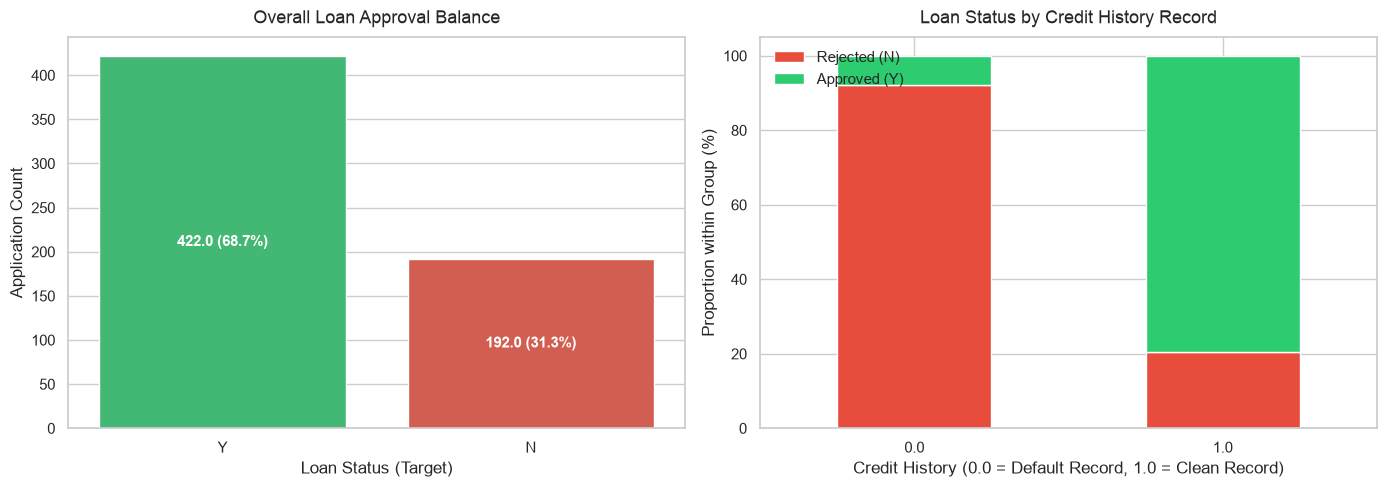

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Target Distribution
sns.countplot(
    data=df, 
    x="Loan_Status", 
    order=["Y", "N"], 
    palette=["#2ecc71", "#e74c3c"], 
    ax=axes[0]
)
axes[0].set_title("Overall Loan Approval Balance", fontsize=13, pad=10)
axes[0].set_xlabel("Loan Status (Target)")
axes[0].set_ylabel("Application Count")

for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f"{h} ({h/len(df)*100:.1f}%)", 
                     (p.get_x() + p.get_width() / 2., h / 2),
                     ha="center", va="center", color="white", fontweight="bold")

# 2. Credit_History vs. Loan_Status
credit_status = pd.crosstab(df["Credit_History"], df["Loan_Status"], normalize="index") * 100
credit_status.plot(
    kind="bar", 
    stacked=True, 
    color=["#e74c3c", "#2ecc71"], 
    ax=axes[1], 
    rot=0
)
axes[1].set_title("Loan Status by Credit History Record", fontsize=13, pad=10)
axes[1].set_xlabel("Credit History (0.0 = Default Record, 1.0 = Clean Record)")
axes[1].set_ylabel("Proportion within Group (%)")
axes[1].legend(["Rejected (N)", "Approved (Y)"], loc="upper left")

plt.tight_layout()
plt.show()

Income & Loan Amount Distributions (Outlier & Skew Diagnosis)

/var/folders/yr/pyshnq8j1hqfvl52ws7vyyj40000gn/T/ipykernel_33170/2695549034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Loan_Status"], y=df["ApplicantIncome"], palette=["#2ecc71", "#e74c3c"], ax=axes[0, 1])
/var/folders/yr/pyshnq8j1hqfvl52ws7vyyj40000gn/T/ipykernel_33170/2695549034.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Loan_Status"], y=df["LoanAmount"], palette=["#2ecc71", "#e74c3c"], ax=axes[1, 1])


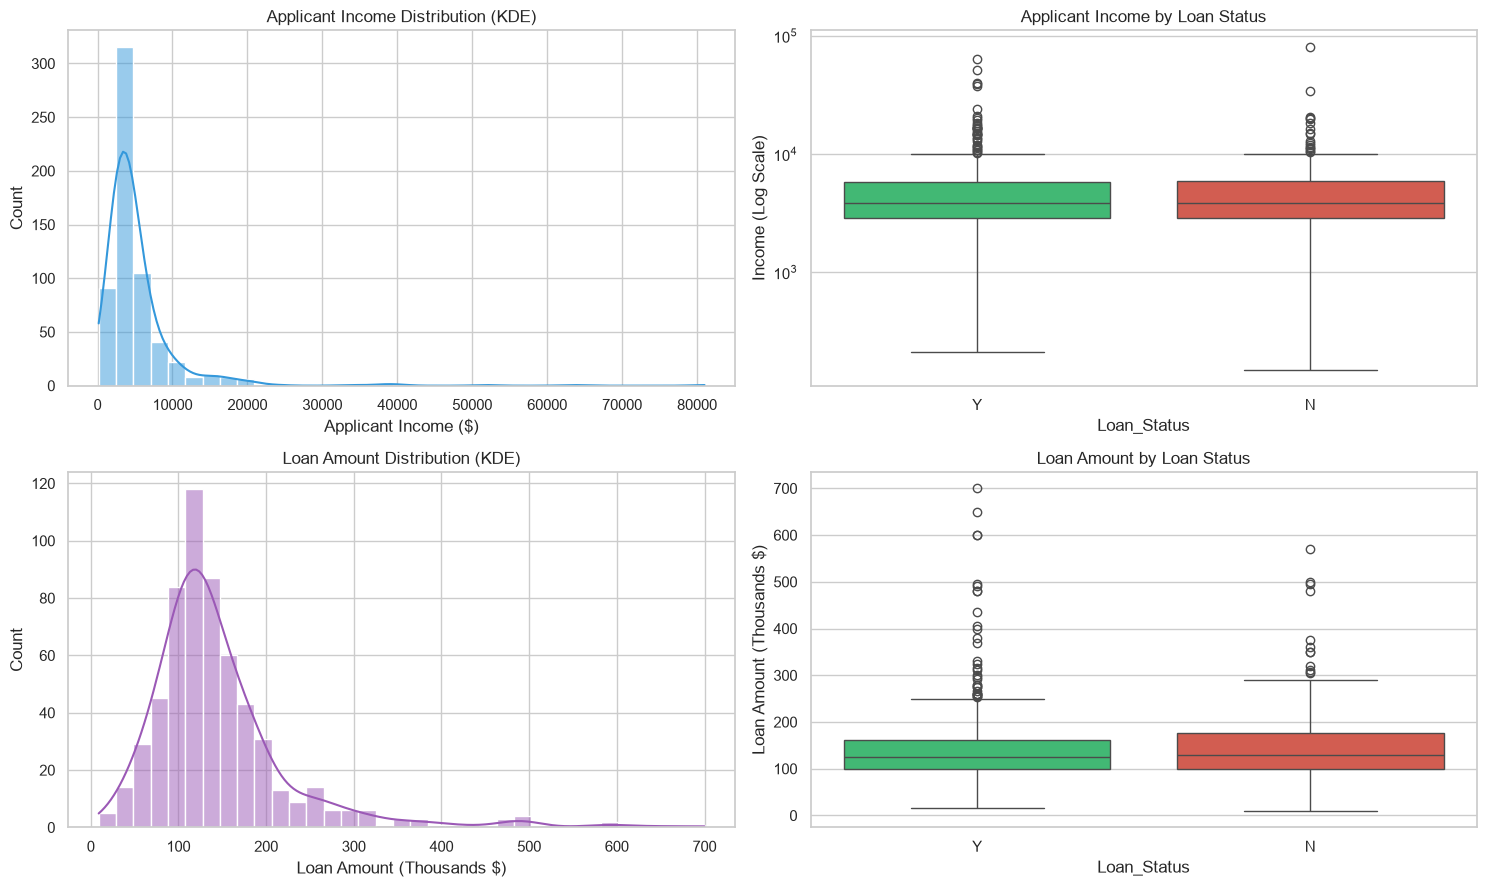

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# ApplicantIncome distribution & boxplot
sns.histplot(df["ApplicantIncome"], kde=True, bins=35, color="#3498db", ax=axes[0, 0])
axes[0, 0].set_title("Applicant Income Distribution (KDE)", fontsize=12)
axes[0, 0].set_xlabel("Applicant Income ($)")

sns.boxplot(x=df["Loan_Status"], y=df["ApplicantIncome"], palette=["#2ecc71", "#e74c3c"], ax=axes[0, 1])
axes[0, 1].set_title("Applicant Income by Loan Status", fontsize=12)
axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel("Income (Log Scale)")

# LoanAmount distribution & boxplot
sns.histplot(df["LoanAmount"].dropna(), kde=True, bins=35, color="#9b59b6", ax=axes[1, 0])
axes[1, 0].set_title("Loan Amount Distribution (KDE)", fontsize=12)
axes[1, 0].set_xlabel("Loan Amount (Thousands $)")

sns.boxplot(x=df["Loan_Status"], y=df["LoanAmount"], palette=["#2ecc71", "#e74c3c"], ax=axes[1, 1])
axes[1, 1].set_title("Loan Amount by Loan Status", fontsize=12)
axes[1, 1].set_ylabel("Loan Amount (Thousands $)")

plt.tight_layout()
plt.show()

Demographic Signals (Marital Status, Education, Dependents, Property Area)

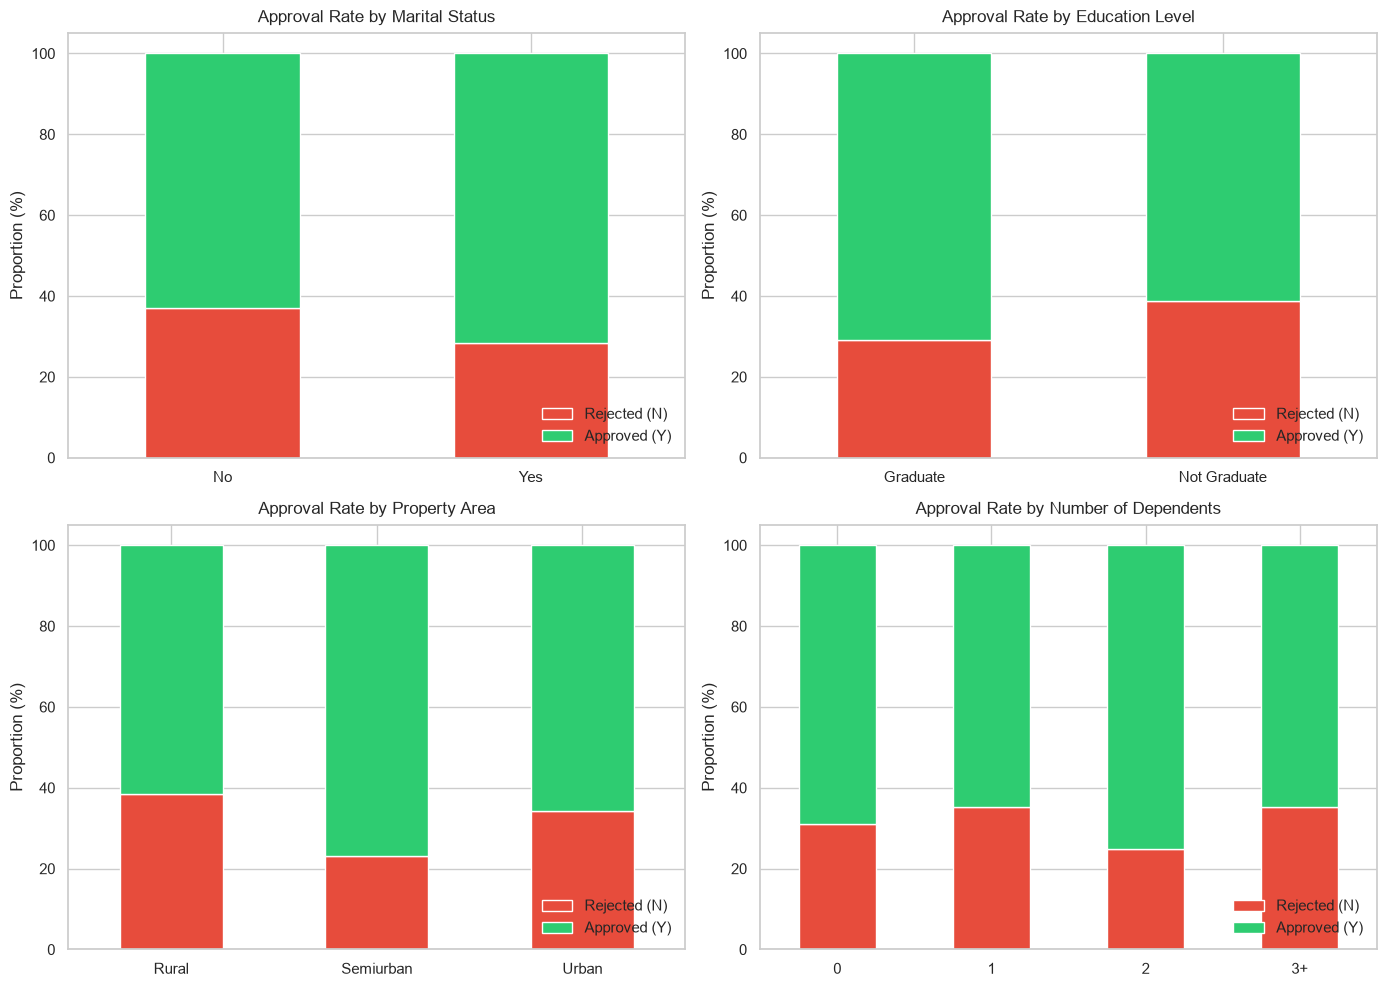

In [15]:
categorical_pairs = [
    ("Married", "Marital Status"),
    ("Education", "Education Level"),
    ("Property_Area", "Property Area"),
    ("Dependents", "Number of Dependents")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col, title) in enumerate(categorical_pairs):
    cross_tab = pd.crosstab(df[col], df["Loan_Status"], normalize="index") * 100
    cross_tab.plot(
        kind="bar", 
        stacked=True, 
        color=["#e74c3c", "#2ecc71"], 
        ax=axes[idx], 
        rot=0
    )
    axes[idx].set_title(f"Approval Rate by {title}", fontsize=12, pad=8)
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Proportion (%)")
    axes[idx].legend(["Rejected (N)", "Approved (Y)"], loc="lower right")

plt.tight_layout()
plt.show()

Employment Status & Combined Income Dynamic

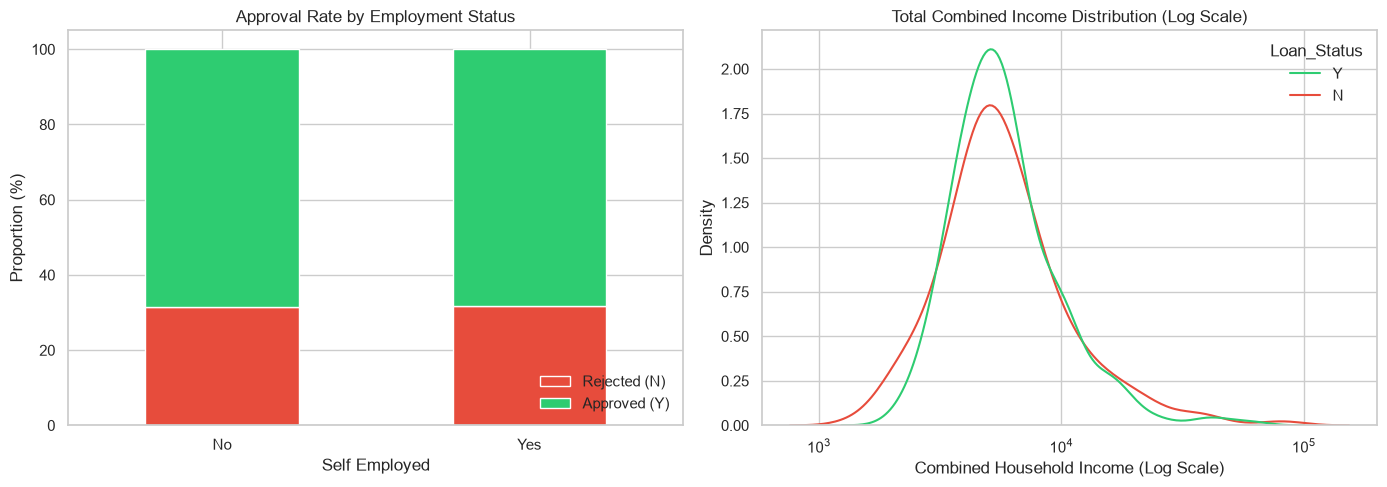

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Self_Employed vs Loan_Status
self_emp_tab = pd.crosstab(df["Self_Employed"], df["Loan_Status"], normalize="index") * 100
self_emp_tab.plot(
    kind="bar", 
    stacked=True, 
    color=["#e74c3c", "#2ecc71"], 
    ax=axes[0], 
    rot=0
)
axes[0].set_title("Approval Rate by Employment Status", fontsize=12)
axes[0].set_xlabel("Self Employed")
axes[0].set_ylabel("Proportion (%)")
axes[0].legend(["Rejected (N)", "Approved (Y)"], loc="lower right")

# Total Income Distribution by Approval
df_temp = df.copy()
df_temp["TotalIncome"] = df_temp["ApplicantIncome"] + df_temp["CoapplicantIncome"]

sns.kdeplot(
    data=df_temp, 
    x="TotalIncome", 
    hue="Loan_Status", 
    palette=["#2ecc71", "#e74c3c"], 
    common_norm=False, 
    log_scale=True, 
    ax=axes[1]
)
axes[1].set_title("Total Combined Income Distribution (Log Scale)", fontsize=12)
axes[1].set_xlabel("Combined Household Income (Log Scale)")

plt.tight_layout()
plt.show()

Feature Isolation & Target Encoding
## 6. Feature Selection & Target Encoding

### Feature Separation
- **Dropped Column**: `Loan_ID` is a non-informative primary key identifier. Keeping it would induce spurious correlation or high-cardinality noise.
- **Predictive Numerical Features**: `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`.
- **Predictive Categorical Features**: `Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `Credit_History`, `Property_Area`. Note: `Credit_History` (values 0.0 or 1.0) is treated as a discrete categorical feature representing creditworthiness status rather than a continuous ratio.

### Target Encoding Mapping
- `Loan_Status = 'Y'` (Approved) $\rightarrow 1$
- `Loan_Status = 'N'` (Rejected) $\rightarrow 0$

In [17]:
# Verify raw target categories
print("Raw unique values in Loan_Status:", df["Loan_Status"].unique())

# Drop non-predictive identifier
df_clean = df.drop(columns=["Loan_ID"]).copy()

# Target mapping: 'Y' -> 1, 'N' -> 0
target_mapping = {"Y": 1, "N": 0}
df_clean["Loan_Status"] = df_clean["Loan_Status"].map(target_mapping)

# Check for any unexpected nulls post-mapping
assert df_clean["Loan_Status"].isnull().sum() == 0, "Target mapping produced NaN values! Check input labels."

# Separate X and y
X = df_clean.drop(columns=["Loan_Status"])
y = df_clean["Loan_Status"].astype(int)

print(f"Target conversion complete.")
print(f"y class balance: 1 (Approved): {(y == 1).sum()} | 0 (Rejected): {(y == 0).sum()}")

Raw unique values in Loan_Status: ['Y' 'N']
Target conversion complete.
y class balance: 1 (Approved): 422 | 0 (Rejected): 192


Stratified Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"X_train shape: {X_train.shape} | y_train length: {len(y_train)}")
print(f"X_test shape:  {X_test.shape}  | y_test length:  {len(y_test)}")

print("\n--- Stratification Verification ---")
train_prop = y_train.value_counts(normalize=True).to_dict()
test_prop = y_test.value_counts(normalize=True).to_dict()

print(f"Train Set - Approved (1): {train_prop[1]*100:.2f}%, Rejected (0): {train_prop[0]*100:.2f}%")
print(f"Test Set  - Approved (1): {test_prop[1]*100:.2f}%, Rejected (0): {test_prop[0]*100:.2f}%")

X_train shape: (491, 11) | y_train length: 491
X_test shape:  (123, 11)  | y_test length:  123

--- Stratification Verification ---
Train Set - Approved (1): 68.64%, Rejected (0): 31.36%
Test Set  - Approved (1): 69.11%, Rejected (0): 30.89%


Construct Scikit-Learn Preprocessing Pipeline

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define feature sets
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
cat_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Credit_History", "Property_Area"]

# 1. Numerical Pipeline: Median Imputation + Standard Scaling
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 2. Categorical Pipeline: Most Frequent Imputation + One-Hot Encoding
# handle_unknown='ignore' protects downstream production deployment against unseen inputs
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# 3. Combined Preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

print("Preprocessing ColumnTransformer constructed successfully.")

Preprocessing ColumnTransformer constructed successfully.


Fit Check & Transformation Shape Verification

In [20]:
# Verify preprocessor transforms training data cleanly without leakage
preprocessor.fit(X_train)

# Transform training set to inspect feature count
X_train_transformed = preprocessor.transform(X_train)
cat_feature_names = preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_cols)
all_feature_names = list(num_cols) + list(cat_feature_names)

print(f"Transformed training matrix shape: {X_train_transformed.shape}")
print(f"Total encoded features: {len(all_feature_names)}")
print("\nEngineered Feature Column Names:")
for i, feat in enumerate(all_feature_names):
    print(f"  [{i:02d}] {feat}")

Transformed training matrix shape: (491, 14)
Total encoded features: 14

Engineered Feature Column Names:
  [00] ApplicantIncome
  [01] CoapplicantIncome
  [02] LoanAmount
  [03] Loan_Amount_Term
  [04] Gender_Male
  [05] Married_Yes
  [06] Dependents_1
  [07] Dependents_2
  [08] Dependents_3+
  [09] Education_Not Graduate
  [10] Self_Employed_Yes
  [11] Credit_History_1.0
  [12] Property_Area_Semiurban
  [13] Property_Area_Urban
